# Tutorial 02: MLR with different types of input variables

#### Lecture and Tutorial Learning Goals:
After completing this week's lecture and tutorial work, you will be able to:

1. Give an example of a real problem that could be answered by a multiple linear regression.
2. Interpret the coefficients and $p$-values of different types of input variables, including categorical input variables.
3. Define interactions in the context of linear regression.
4. Write a computer script to perform linear regression when input variables are continuous or discrete and when there are interactions between some variables.

In [1]:
# Run this cell before continuing.
library(tidyverse)
library(cowplot)
#library(repr)
#library(infer)
library(broom)
library(AER)
library(modelr)
source("tests_tutorial_02.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some


Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:



## The data

In this tutorial, we will continue using the `CASchools` real world dataset from 420 K-6 and K-8 districts in California. The California School data set comes with an R package called `AER`, an acronym for Applied Econometrics with R (by Christian Kleiber & Zeileis, 2017). 

The dataset contains data on test performance, school characteristics, and student demographic backgrounds in Californian school districts. Among many variables available, we will use the following:

- `grades`: factor indicating grade span of district.

- `income`: District average income (in USD 1,000).

- `english`: Percent of English learners.

- `read`: Average reading score.


In [2]:
# Run this cell
data(CASchools)

caschools <- 
    CASchools %>%
    select(grades, income, english, read) %>%
    mutate_if(is.numeric, round, 2)

head(caschools)

,grades,income,english,read
,<fct>,<dbl>,<dbl>,<dbl>
1,KK-08,22.69,0.00,691.6
2,KK-08,9.82,4.58,660.5
3,KK-08,8.98,30.00,636.3
4,KK-08,8.98,0.00,651.9
5,KK-08,9.08,13.86,641.8
6,KK-08,10.41,12.41,605.7


<font style='color: darkred'>**Note:** Make sure that categorical variables in your model are factors. If the categorical variable is not a factor, `lm` won't create a dummy variable. </font> 

## 1. MLR: additive

As discussed in the lecture, `lm()` will create dummy variables to include categorical variables in the model. In this example, `grades` is a categorical variable with 2 levels. 

**Question 1.0**
<br>{points: 1}

The input variable `grades` is a discrete nominal variable with 2 levels, KK-06 and KK-08. Since this variable is a factor in the dataset, `lm()` selects one level as a baseline to create a dummy variable. Which level of `grades` is selected, by default, as a baseline?

> you can add a cell below and use the function `levels()` to check. 

**A.** `KK-06`

**B.** `KK-08`

*Assign your answer to an object called `answer1.0`. Your answer should be one of `"A"` or `"B"` surrounded by quotes.*

In [3]:
levels(caschools$grades)

[1] "KK-06" "KK-08"

In [4]:
# answer1.0 <- ...

# your code here
answer1.0 <- "A"

In [5]:
test_1.0()

Test passed 🌈
Test passed 😀
Test passed 🥳
[1] "Success!"


**Question 1.1**
<br>{points: 1}

How many dummy variables will `lm()` create to fit a linear regression with the categorical variable `grades`?

**A.** 1

**B.** 2

**C.** 3

**D.** 4

*Assign your answer to an object called `answer1.1`. Your answer should be one of `"A"`, `"B"`, `"C"`, or `"D"` surrounded by quotes.*

In [6]:
# answer1.1 <- 

# your code here
answer1.1 <- "A"

In [7]:
test_1.1()

Test passed 🥳
Test passed 🎊
Test passed 🎊
[1] "Success!"


**Question 1.2**
<br>{points: 1}

In the previous tutorial, you used a simple linear regression (SLR) to study the relation between `read` and `income` on average for all types of schools. Suppose you want to examine whether this relation differs depending on the school's grade span (i.e., KK-06 vs KK-08). 

If you expect the same change in reading score per unit difference in the average income for all types of school (i.e., for all levels of `grades`), which MLR will you fit using the `lm()` function?

**A.** `lm(read ~ income + grades, data = caschools)`

**B.** `lm(read ~ income * grades, data = caschools)`

*Assign your answer to an object called `answer1.2`. Your answer should be one of `"A"` or `"B"` surrounded by quotes.*

In [8]:
# answer1.2 <- 

# your code here
answer1.2 <- "A"

In [9]:
test_1.2()

Test passed 😸
Test passed 🥳
Test passed 😀
[1] "Success!"


**Question 1.3**
<br>{points: 1}

Which of the following descriptions will best describe a visualization of the MLR considered in *Question 1.2*? 

**A.** one line through a cloud of data points

**B.** two lines with equal slopes but different intercepts

**C.** two lines with different slopes and different intercepts

**D.** a smooth concave curve through a cloud of data points

**E.** two boxplots for different levels of `grades`

*Assign your answer to an object called `answer1.3`. Your answer should be one of `"A"`, `"B"`, `"C"`, `"D"`, or `"E"` surrounded by quotes.*

In [10]:
# answer1.3 <- 

# your code here
answer1.3 <- "B"

In [11]:
test_1.3()

Test passed 🥇
Test passed 😀
Test passed 😀
[1] "Success!"


**Question 1.4**
<br>{points: 1}

Using `caschools`, fit the MLR proposed in *Question 1.2*. Store the result in an object called `caschools_MLR_add`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [12]:
# caschools_MLR_add <- ...(..., ...)

# your code here
caschools_MLR_add <- lm(read ~ income + grades, data=caschools)

caschools_MLR_add


Call:
lm(formula = read ~ income + grades, data = caschools)

Coefficients:
(Intercept)       income  gradesKK-08  
    627.144        1.926       -1.967  


In [13]:
test_1.4.0()
test_1.4.1()
test_1.4.2()

Test passed 😸
Test passed 🎊
[1] "Success!"
Test passed 🥇
Test passed 🎉
[1] "Success!"
Test passed 🌈
Test passed 😸
[1] "Success!"


**Question 1.5**
<br>{points: 1}

Create a scatterplot of the data in `caschools` along with the estimated regression lines from the additive regression model `caschools_MLR_add`. 

- Use different colours for the points and regression lines of each type of school (levels of `grades`). 
- Include a legend indicating the colour of each level with proper axis labels. 

The `ggplot()` object's name will be `caschools_MLR_add_plot`.

*Hint: Start by computing the predictions of the fitted model (the function `add_predictions` can be handy). Store the predictions in a new column named `pred_MLR_additive`.*



*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

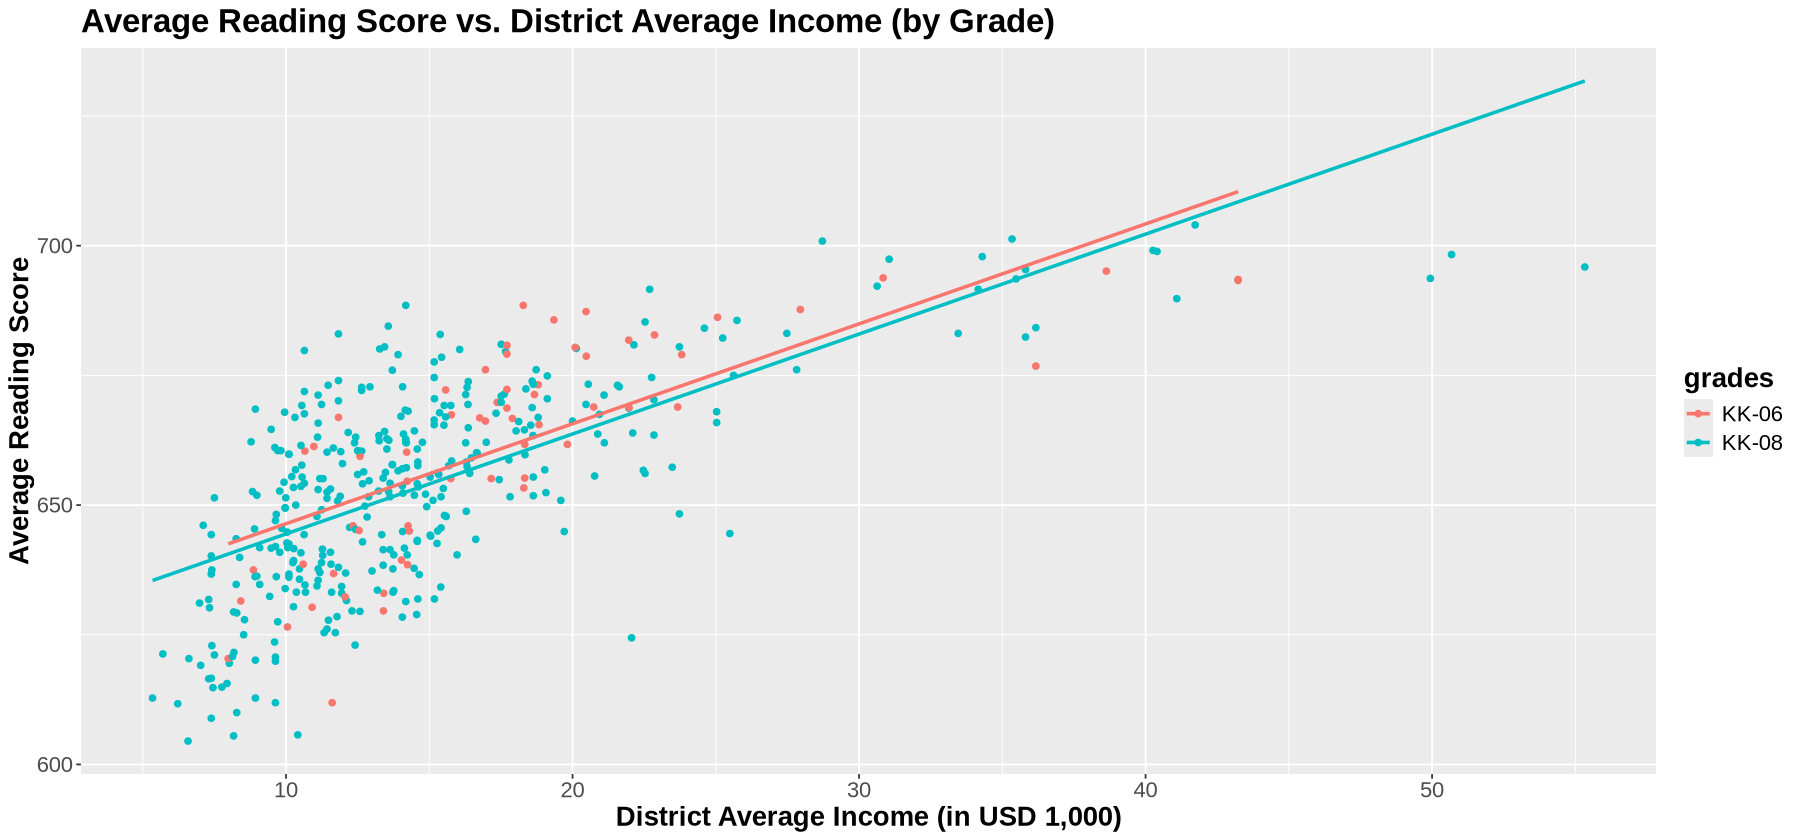

In [14]:
# Adjust these numbers so the plot looks good in your desktop.
options(repr.plot.width = 15, repr.plot.height = 7)

# caschools <-
#     ... %>% 
#     ...(..., var = 'pred_MLR_additive')

# caschools_MLR_add_plot <- 
#     ... %>%
#     ggplot(aes(x = ...,y = ..., color = ...)) +
#     ...() +
#     ...(aes(y = ...), linewidth = 1) +
#     labs(title = ...,
#          x = ...,
#          y = ...) +
#     theme(text = element_text(size = 16.5),
#           plot.title = element_text(face = "bold"),
#           axis.title = element_text(face = "bold"),
#           legend.title = element_text(face = "bold")) +
#     labs(color = "grades")

# your code here
caschools <-
    caschools %>% 
    add_predictions(caschools_MLR_add, var = 'pred_MLR_additive')

caschools_MLR_add_plot <- 
    caschools %>%
    ggplot(aes(x = income,y = read, color = grades)) +
    geom_point() +
    geom_line(aes(y = pred_MLR_additive), linewidth = 1) +
    labs(title = "Average Reading Score vs. District Average Income (by Grade)",
         x = "District Average Income (in USD 1,000)",
         y = "Average Reading Score") +
    theme(text = element_text(size = 16.5),
          plot.title = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          legend.title = element_text(face = "bold")) +
    labs(color = "grades")

caschools_MLR_add_plot

💡 **Alternative way to visualize parallel LS lines**

In Question 1.5, you generated the predicted values and plot them. Alternatively, you can use the function `geom_parallel_slopes()` from the `moderndive` package to draw parallel least-squares lines for additive models with a categorical predictor. We'll use it later in the course.

In [15]:
test_1.5()

Test passed 😀
Test passed 😀
Test passed 😀
Test passed 😀
Test passed 🎊
Test passed 😸
Test passed 😸
Test passed 🌈
[1] "Success!"


**Question 1.6**
<br>{points: 1}

Find the estimated coefficients of `caschools_MLR_add` using `tidy()`. Report the estimated coefficients, their standard errors and corresponding $p$-values. Include the corresponding asymptotic **90% confidence intervals**. 

Store the results in the variable `caschools_MLR_add_results`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [16]:
# caschools_MLR_add_results <-
    # ...(..., ..., ....) %>% 
    # mutate_if(is.numeric, round, 2)

# your code here
caschools_MLR_add_results <-
    tidy(caschools_MLR_add, conf.int=TRUE, conf.level=0.90) %>% 
    mutate_if(is.numeric, round, 2)

caschools_MLR_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),627.14,2.57,243.80,0.00,622.90,631.39
income,1.93,0.10,19.50,0.00,1.76,2.09
gradesKK-08,-1.97,2.02,-0.97,0.33,-5.30,1.37


In [17]:
test_1.6()

Test passed 🎊
Test passed 😸
Test passed 🎊
Test passed 😸
Test passed 🥇
Test passed 🌈
Test passed 🥇
Test passed 🎊
Test passed 🌈
Test passed 🎉
[1] "Success!"


**Question 1.7**
<br>{points: 1}

Considering the results in `caschools_MLR_add_results` from *Question 1.6*, how would you interpret the estimated coefficient of the continuous variable `income` ?

> *The estimated coefficient of the continuous variable `income` is the average increase in reading score that is associated with a district average income increase by 1,000 USD while holding grade constant. More specifically, every 1,000 USD increase in district average income is associated with an estimated `1.93` reading score increase while holding grade constant (i.e. keeping it as `KK-06` or `KK-08`).*

**Question 1.8**
<br>{points: 1}

Using a significance level $\alpha = 0.10$, which of the following claims are correct?


**A.** for any average income, the expected reading score is the same for schools with KK-06 and schools with KK-08 grades. 

**B.** there is enough evidence to reject the hypothesis that, for any average income, the expected reading score is the same for schools with KK-06 and schools with KK-08 grades.

**C.** for any school type, the reading test score (`read`) is significantly associated with the average district income (`income`). 

**D.** there is enough evidence to believe that the association between `income` and `read` varies depending on the grade span of the school.


*Assign your answers to the object `answer1.8`. Your answers have to be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., `"ABCD"` indicates you are selecting the four options).*

In [18]:
# answer1.8 <- 

# your code here
answer1.8 <- "C"

In [19]:
test_1.8()

Test passed 🎊
Test passed 🥳
Test passed 🎊
[1] "Success!"


**Question 1.9**
<br>{points: 1}

In one or two sentences, explain what "statistically significant" means in the following sentence and how it differs from "practical significance".

> "the reading test score (read) is significantly associated with the average district income (income)"


> *"Statistically significant" means we are confident that reading test score is generally associated with the average district income when looking at all of the data points and therefore the trend between these variables is not simply a coincidence (i.e. there appears to be a trend between these two variables) and therefore does not indicate the exact relationship necessarily, but rather rejects the hypothesis that the reading test score and average district income are unrelated. "Practical signifiance" is whether the magnitude of the association between reading test score and average district income is large enough to actually matter in the real world.*

## 2. MLR: with interactions

In this section, we will explore whether the relation between `read` and `income` is the same for all school types. We can do this using *interactions* between the input variables!

Note that interactions can be used when the relation between an input and the response depends on another input variable (not necessarily categorical!).

**Question 2.0**
<br>{points: 1}

We can use `lm()` to fit the MLR with interactions between the continuous variable `income` and the categorical variable `grades` (with 2 levels) defined above.

How many regression coefficients will be estimated by `lm()`?

**A.** 1

**B.** 2

**C.** 3

**D.** 4


*Assign your answer to an object called `answer2.0`. Your answer should be one of `"A"`, `"B"`, `"C"`, `"D"`, `"E"`, or `"F"` surrounded by quotes.*

In [20]:
# answer2.0 <- 

# your code here
answer2.0 <- "D"

In [21]:
test_2.0()

Test passed 🎉
Test passed 🥳
Test passed 🎉
[1] "Success!"


**Question 2.1**
<br>{points: 1}

Using `caschools`, fit the MLR with the interaction described above and call it `caschools_MLR_int`.

*Hint: Interaction terms can be easily specified in `lm()` using the notation `*`.*


*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [22]:
# caschools_MLR_int <- ...(..., ...)

# your code here
caschools_MLR_int <- lm(read ~ income * grades, data=caschools)

caschools_MLR_int


Call:
lm(formula = read ~ income * grades, data = caschools)

Coefficients:
       (Intercept)              income         gradesKK-08  income:gradesKK-08  
         625.46764             2.01893            -0.02607            -0.11025  


In [23]:
test_2.1.0()
test_2.1.1()
test_2.1.2()
test_2.1.3()

Test passed 😀
Test passed 🎉
[1] "Success!"
Test passed 😀
Test passed 🥳
[1] "Success!"
Test passed 🌈
Test passed 🎊
[1] "Success!"
Test passed 🎊
Test passed 😀
[1] "Success!"


**Question 2.2**
<br>{points: 1}

Create a scatterplot of the data in `caschools` along with the estimated regression lines from the regression model with interaction `caschools_MLR_int`. 

- Use different colours for the points and regression lines of each type of school (levels of `grades`). 
- Include a legend indicating the colour of each level with proper axis labels. 

The `ggplot()` object's name will be `caschools_MLR_int_plot`.

*Hint: Start by computing the predictions of the fitted model (the function `add_predictions` can be handy). Store the predictions in a new column named `pred_MLR_interaction`.*

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

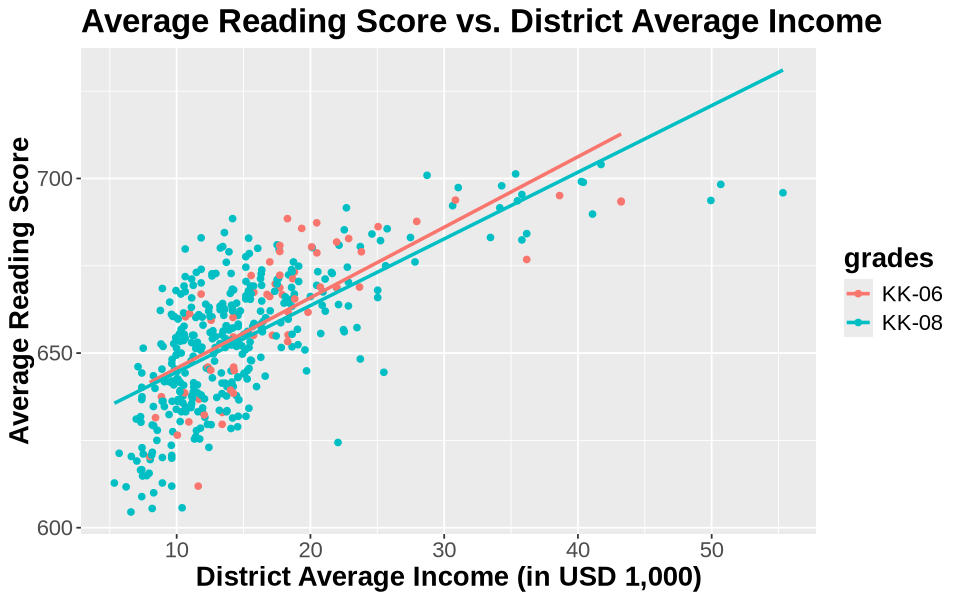

In [24]:
# Adjust these numbers so the plot looks good in your desktop.
options(repr.plot.width = 8, repr.plot.height = 5)

# caschools <-
#     ... %>% 
#     ...(..., var = 'pred_MLR_interaction')

# caschools_MLR_int_plot <- 
#     ... %>%
#     ggplot(aes(x = ...,y = ..., color = ...)) +
#     ...() +
#     ...(aes(y = ...), linewidth = 1) +
#     labs(title = ...,
#          x = ...,
#          y = ...) +
#     theme(text = element_text(size = 16.5),
#           plot.title = element_text(face = "bold"),
#           axis.title = element_text(face = "bold"),
#           legend.title = element_text(face = "bold")) +
#     labs(color = "grades")

# your code here
caschools <-
    caschools %>% 
    add_predictions(caschools_MLR_int, var = 'pred_MLR_interaction')

caschools_MLR_int_plot <- 
    caschools %>%
    ggplot(aes(x = income,y = read, color = grades)) +
    geom_point() +
    geom_line(aes(y = pred_MLR_interaction), linewidth = 1) +
    labs(title = "Average Reading Score vs. District Average Income",
         x = "District Average Income (in USD 1,000)",
         y = "Average Reading Score") +
    theme(text = element_text(size = 16.5),
          plot.title = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          legend.title = element_text(face = "bold")) +
    labs(color = "grades")

caschools_MLR_int_plot

💡 **Alternative way to visualize non-parallel LS lines**

Since two groups are create by `aes()` argument of `ggplot()`, the `geom_smooth()` function fits a smooth curve to each group. Thus, using arguments `geom_smooth(method = "lm", se = FALSE)`, we can also add one LS line to each group. 

Note that `geom_smooth()` does not fit a LR model to all the data, it fits a LS line to each group. Thus, it cannot be used to add parallel lines from an additive LR model! 

In Question 2.7, you'll show that the estimated lines of a MLR with interaction are equivalent to those estimated by SLR on separate groups, thus `geom_smooth()` can be used to visualize each line in this case.

In [25]:
test_2.2()

Test passed 😀
Test passed 🥳
Test passed 🎉
Test passed 🥇
Test passed 🥇
Test passed 🎉
Test passed 🌈
Test passed 🌈
[1] "Success!"


**Question 2.3**
<br>{points: 1}

Find the estimated coefficients of `caschools_MLR_int` using `tidy()`. Report the estimated coefficients, their standard errors and corresponding $p$-values. Include the corresponding asymptotic 90% confidence intervals. Store the results in the variable `caschools_MLR_int_results`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [26]:
# caschools_MLR_int_results <- 
#    ...(..., ..., ....) %>%
#    mutate_if(is.numeric, round, 2)

# your code here
caschools_MLR_int_results <- 
   tidy(caschools_MLR_int, conf.int=TRUE, conf.level=0.90) %>%
   mutate_if(is.numeric, round, 2)

caschools_MLR_int_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),625.47,4.83,129.43,0.00,617.50,633.43
income,2.02,0.25,8.20,0.00,1.61,2.42
gradesKK-08,-0.03,5.15,-0.01,1.00,-8.51,8.46
income:gradesKK-08,-0.11,0.27,-0.41,0.68,-0.55,0.33


In [27]:
test_2.3()

Test passed 🥇
Test passed 🥳
Test passed 😸
Test passed 😸
Test passed 😀
Test passed 🎊
Test passed 🥳
Test passed 🥇
Test passed 🎉
Test passed 🎊
[1] "Success!"


**Question 2.4**
<br>{points: 1}

Using a significance level $\alpha = 0.10$, which of the following claims are correct?


**A.** There is enough evidence to reject the hypothesis that, for any average income, the expected reading score is the same for schools with KK-06 and schools with KK-08 grades.

**B.** For any school type, the change in `read` per unit change in `income` is statistically significant.

**C.** There is enough evidence to reject the hypothesis that the change in `read` per unit change in `income` is the same for schools with KK-06 and schools with KK-08 grades.

**D.** There is not enough evidence to reject the hypothesis that the association between `income` and `read` is the same for schools with KK-06 and schools with KK-08 grades.

**E.** For schools with KK-06 grade span, the reading test score (`read`) is significantly associated with the average district income (`income`).

*Assign your answers to the object `answer2.4`. Your answers have to be included in a single string indicating the correct options **in alphabetical order** and surrounded by quotes (e.g., `"ABCDE"` indicates you are selecting the seven options).*

In [28]:
# answer2.4 <- 

# your code here
answer2.4 <- "DE"

In [29]:
test_2.4()

Test passed 🥇
Test passed 🌈
Test passed 😸
[1] "Success!"


**Question 2.5**
<br>{points: 1}

A common practice is not to interpret coefficients that are not statistically significant since based on the data, they are not significantly different from 0. The estimates just reflect noise in the data. Alternatively, you can provide an interpretation but with the caveat that the result is not statistically significant.  

Following the second approach, what would be a correct interpretation of the estimated coefficient of the interaction term `income:gradesKK-08` from `caschools_MLR_int_results` in *Question 2.3*? (remember to comment on the significance of the result).

> The `-0.11` estimate for the `income:gradesKK-08` term means that `KK-08` is associated with a `2.02 + (-0.11) = 1.91` increase in reading score for every 1,000 USD increase in average district income, whereas `KK-06` is associated with a `2.02` increase. However, we must conduct a hypothesis test to see if this estimate is statistically significant. We can then see that the interaction term `income:gradesKK-08` is not statistically significant and therefore there is no evidence to support a difference in the impact income has on reading score between different grades. This is because the p-value falls above 0.10 which is the significance level we have set.*

**Question 2.6**
<br>{points: 1}

Fit the following 3 models as indicated:

**A.** a SLR with `read` as the response and `income` as the *only* input variable using only KK-06 schools in `caschools`. Use `tidy` to get estimated parameters and standard errors. Call the results `caschools_SLR_kk06_results`

**B.** a SLR with `read` as the response and `income` as the *only* input variable using only KK-08 schools in `caschools`. Use `tidy` to get estimated parameters and standard errors. Call the results `caschools_SLR_kk08_results`

**C.** a MLR with `read` as the response and `income` and `grades` as input variables, *including their interaction*, using `caschools`. Note that you already have the estimated parameters and standard errors in `caschools_MLR_int_results`. 

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [30]:
# caschools_SLR_kk06_results <- 
#    tidy(lm(... ~ ..., data = subset(...,... == ...))) %>%
#    mutate_if(is.numeric, round, 2)


# caschools_SLR_kk08_results <- 
#    tidy(lm(... ~ ..., data = subset(...,... == ...))) %>%
#    mutate_if(is.numeric, round, 2)

# your code here
caschools_SLR_kk06_results <- 
   tidy(lm(read ~ income, data = subset(caschools,grades == "KK-06"))) %>%
   mutate_if(is.numeric, round, 2)


caschools_SLR_kk08_results <- 
   tidy(lm(read ~ income, data = subset(caschools,grades == "KK-08"))) %>%
   mutate_if(is.numeric, round, 2)

caschools_SLR_kk06_results
caschools_SLR_kk08_results
caschools_MLR_int_results

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),625.47,4.62,135.35,0
income,2.02,0.24,8.57,0


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),625.44,1.79,350.10,0
income,1.91,0.11,17.55,0


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),625.47,4.83,129.43,0.00,617.50,633.43
income,2.02,0.25,8.20,0.00,1.61,2.42
gradesKK-08,-0.03,5.15,-0.01,1.00,-8.51,8.46
income:gradesKK-08,-0.11,0.27,-0.41,0.68,-0.55,0.33


In [31]:
test_2.6.0()
test_2.6.1()
test_2.6.2()

Test passed 🥇
Test passed 😀
Test passed 🥇
Test passed 🌈
Test passed 🎉
Test passed 🎊
Test passed 😀
Test passed 🎉
[1] "Success!"
Test passed 😀
Test passed 🥳
Test passed 😸
Test passed 🥳
Test passed 😀
Test passed 🥳
Test passed 🎉
Test passed 🥳
[1] "Success!"
Test passed 🌈
Test passed 🎊
Test passed 🥳
Test passed 😸
Test passed 😸
Test passed 😸
Test passed 😸
Test passed 🥳
Test passed 🌈
Test passed 🥳
[1] "Success!"


**Question 2.7**
<br>{points: 1}

**2.7.0** Using the results from `caschools_SLR_kk06_results` and `caschools_MLR_int_results` in *Question 2.6*, explain why the estimated coefficients of `income` are the same in both models

**2.7.1** Using the results from `caschools_SLR_kk08_results` and `caschools_MLR_int_results` in *Question 2.6*, explain why the estimated coefficients of `income` are *not* the same in both models. 

**2.7.2** Explain why the estimated coefficients of `income` in `caschools_SLR_kk08_results` is *not* the same as that of `income:gradesKK-08` in `caschools_MLR_int_results` using the results from *Question 2.6*.

> *2.7.0: The estimated coefficients of `income` are the same in both the `caschools_SLR_kk06_results` and `caschools_MLR_int_results` tables since `KK-06` is the reference category. The dummy variable introduced is an indicator of `KK-08` so for `KK-06` observations, the covariate is 0.*

> *2.7.1: The esimated coefficients of `income` are **not** the same in `caschools_SLR_kk08_results` and `caschools_MLR_int_results` because `KK-08` is not the reference category. However, the estimated coefficient of `income` in `caschools_SLR_kk08_results` can be retrieved from the `caschools_MLR_int_results` table by taking the `income` and adding the interaction term `income:gradesKK-08`: `2.02 + (-0.11) = 1.91`*

> *2.7.2: The estimated coefficients of `income` in `caschools_SLR_kk08_results` is not the same as `income:gradesKK-08` in `caschools_MLR_int_results` since `income:gradesKK-08` is the coefficient responsible for any extra influence `income` has on reading scores that is specific to `KK-08` grades. However, the p-value for the interaction feature `income:gradesKK-08` has a p-value of `0.68` which means that we would fail to reject the null hypothesis at even a 0.10 significance level. Therefore there isn't enough evidence that supports the claim that `income` would have a different effect on the reading score for `KK-06` and `KK-08`.*